# PHASE 4 - Linear Regression

This notebook trains a Linear Regression model using the chronological splits created in PHASE 3. It reports MAE, RMSE, R2, and training time for validation and test data.

Leakage prevention: `casual`, `registered`, and `cnt` are excluded from predictors. The scaler is fit only on the training set through a scikit-learn Pipeline.

In [ ]:
# Nhập các thư viện cần thiết
from pathlib import Path  # Làm việc với đường dẫn file
from time import perf_counter  # Đo thời gian thực thi
import pickle  # Lưu và tải các object Python

import matplotlib.pyplot as plt  # Vẽ đồ thị
import pandas as pd  # Xử lý dữ liệu
from sklearn.linear_model import LinearRegression  # Model Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Các hàm tính metrics
from sklearn.pipeline import Pipeline  # Tạo pipeline xử lý liên tiếp
from sklearn.preprocessing import StandardScaler  # Chuẩn hóa dữ liệu

# Tùy chọn hiển thị tất cả các cột trong pandas
pd.set_option("display.max_columns", None)

# Tìm thư mục gốc (có thể chạy từ thư mục gốc hoặc thư mục notebooks)
base_dir = Path(".") if (Path(".") / "data/processed/train.csv").exists() else Path("..")

# Định nghĩa các đường dẫn thư mục
processed_dir = base_dir / "data/processed"  # Thư mục dữ liệu đã xử lý
results_dir = base_dir / "results"  # Thư mục kết quả
metrics_dir = results_dir / "metrics"  # Thư mục lưu metrics
figures_dir = results_dir / "figures"  # Thư mục lưu hình
models_dir = base_dir / "models"  # Thư mục lưu mô hình

# Tạo các thư mục nếu chưa tồn tại
for directory in [metrics_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

In [ ]:
# Hàm tải dữ liệu từ file CSV
def load_split(name):
    path = processed_dir / f"{name}.csv"  # Tạo đường dẫn file
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run PHASE 3 first.")  # Kiểm tra file tồn tại
    return pd.read_csv(path, parse_dates=["timestamp", "dteday"])  # Đọc file và chuyển cột thành datetime

# Tải 3 tập dữ liệu từ PHASE 3
train_df = load_split("train")  # Dữ liệu huấn luyện
validation_df = load_split("validation")  # Dữ liệu xác thực
test_df = load_split("test")  # Dữ liệu kiểm tra

# === CHUẨN BỊ DỮ LIỆU ===
target_column = "cnt"  # Cột mục tiêu: số lượng xe đạp được thuê

# Các cột cần loại bỏ (để tránh rò rỉ dữ liệu và cột không cần thiết)
excluded_columns = {
    target_column,  # Mục tiêu (sẽ là y, không phải X)
    "instant",  # ID hàng
    "dteday",  # Ngày tháng năm
    "timestamp",  # Thời gian
    "casual",  # Số lượng casual users (không được dùng làm feature)
    "registered",  # Số lượng registered users (không được dùng làm feature)
}

# Lấy tất cả cột có trong train_df trừ các cột loại bỏ
feature_columns = [column for column in train_df.columns if column not in excluded_columns]

# Chia dữ liệu thành X (features) và y (target) cho mỗi tập
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_validation, y_validation = validation_df[feature_columns], validation_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

# In thông tin về dữ liệu
print(f"Features: {len(feature_columns)}")  # Số lượng features
print(feature_columns)  # Danh sách features
print(f"Train/validation/test: {len(train_df)}/{len(validation_df)}/{len(test_df)}")  # Kích thước các tập

Features: 27
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'hour', 'day', 'month', 'year', 'day_of_week', 'day_of_year', 'is_weekend', 'is_workingday', 'rush_hour', 'lag_1', 'lag_2', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168']
Train/validation/test: 12047/2582/2582


## Fit on train only

In [ ]:
# Tạo Pipeline: một chuỗi các bước xử lý dữ liệu
# Bước 1: Chuẩn hóa dữ liệu (StandardScaler) - để các features có cùng quy mô
# Bước 2: Huấn luyện Linear Regression model
model = Pipeline([
    ("scaler", StandardScaler()),  # Chuẩn hóa: (X - mean) / std
    ("regressor", LinearRegression()),  # Linear Regression: y = w1*X1 + w2*X2 + ... + b
])

# Bắt đầu đo thời gian
start_time = perf_counter()

# Huấn luyện model: 
# - Chuẩn hóa X_train
# - Tìm các hệ số tối ưu cho Linear Regression
model.fit(X_train, y_train)

# Kết thúc đo thời gian
training_time = perf_counter() - start_time

# Dự đoán trên tập validation
validation_predictions = model.predict(X_validation)

# Dự đoán trên tập test
test_predictions = model.predict(X_test)

# In thời gian huấn luyện
print(f"Training time: {training_time:.4f} seconds")

Training time: 0.0693 seconds


In [ ]:
# Hàm tính các metrics (chỉ số đánh giá) cho model
def regression_metrics(y_true, predictions, split_name):
    return {
        "model": "Linear Regression",  # Tên model
        "split": split_name,  # Tên tập (validation hoặc test)
        
        # MAE (Mean Absolute Error): Trung bình của giá trị tuyệt đối sai số
        # Càng nhỏ càng tốt. Đơn vị: số lượng xe đạp
        "MAE": mean_absolute_error(y_true, predictions),
        
        # RMSE (Root Mean Squared Error): Căn bậc hai của trung bình sai số bình phương
        # Một cách khác để đo lỗi dự đoán (nhạy hơn với lỗi lớn)
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        
        # R² (R-squared): Tỷ lệ phương sai được model giải thích
        # 1.0 = dự đoán hoàn hảo, 0.0 = model không tốt hơn lấy trung bình
        "R2": r2_score(y_true, predictions),
        
        # Thời gian huấn luyện
        "Training Time": training_time,
    }

# Tính metrics cho cả validation và test
metrics = pd.DataFrame([
    regression_metrics(y_validation, validation_predictions, "validation"),  # Metrics trên validation
    regression_metrics(y_test, test_predictions, "test"),  # Metrics trên test
])

# Hiển thị metrics (làm tròn 4 chữ số thập phân)
display(metrics.round(4))

# Lưu metrics vào file CSV
metrics.to_csv(metrics_dir / "linear_regression_metrics.csv", index=False)
print(f"Saved metrics to: {metrics_dir / 'linear_regression_metrics.csv'}")

,model,split,MAE,RMSE,R2,Training Time
0,Linear Regression,validation,57.6307,81.3603,0.8684,0.0693
1,Linear Regression,test,57.7926,83.9422,0.8461,0.0693


Saved metrics to: results\metrics\linear_regression_metrics.csv


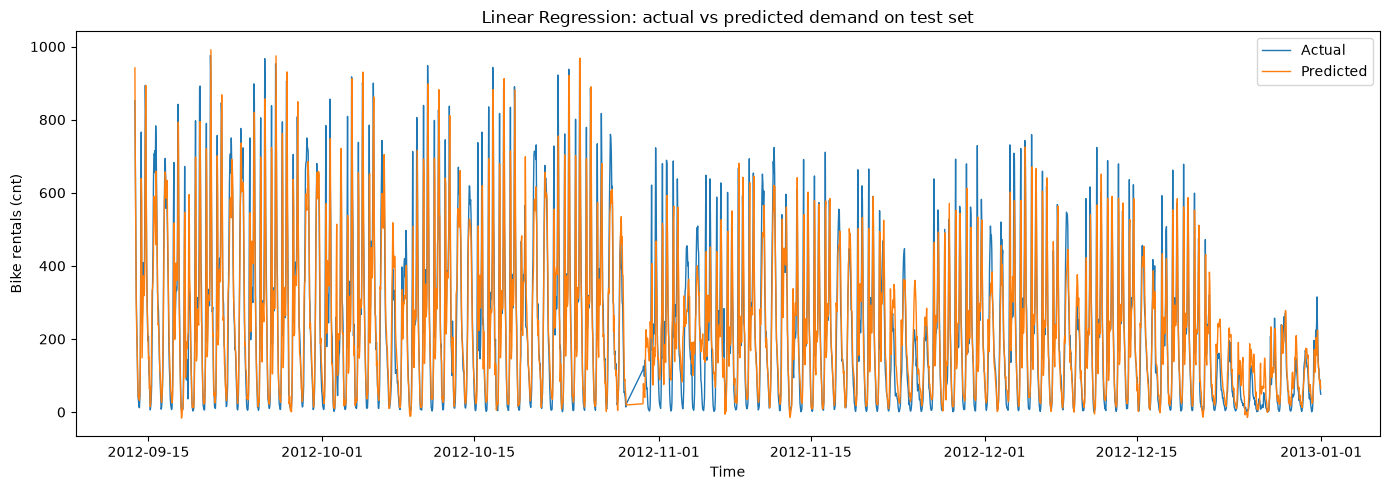

In [ ]:
# Tạo DataFrame so sánh giá trị thực tế và dự đoán trên tập test
comparison = pd.DataFrame({
    "timestamp": test_df["timestamp"],  # Thời gian
    "actual": y_test.to_numpy(),  # Giá trị thực tế (số xe đạp được thuê)
    "predicted": test_predictions,  # Giá trị dự đoán của model
})

# Tạo biểu đồ với kích thước 14x5 inch
plt.figure(figsize=(14, 5))

# Vẽ đường thực tế (màu đầu tiên)
plt.plot(comparison["timestamp"], comparison["actual"], label="Actual", linewidth=1)

# Vẽ đường dự đoán (màu thứ hai)
plt.plot(comparison["timestamp"], comparison["predicted"], label="Predicted", linewidth=1)

# Đặt tiêu đề và nhãn trục
plt.title("Linear Regression: actual vs predicted demand on test set")
plt.xlabel("Time")
plt.ylabel("Bike rentals (cnt)")

# Thêm chú thích (legend) để phân biệt 2 đường
plt.legend()

# Điều chỉnh layout để tránh bị cắt
plt.tight_layout()

# Lưu biểu đồ thành file ảnh
plt.savefig(figures_dir / "linear_regression_actual_vs_predicted.png", dpi=150)

# Hiển thị biểu đồ
plt.show()

In [ ]:
# Định nghĩa đường dẫn lưu model
model_path = models_dir / "linear_regression.pkl"

# Mở file ở chế độ ghi nhị phân (wb = write binary)
with model_path.open("wb") as model_file:
    # Lưu model và danh sách features vào file bằng pickle
    # Lưu cả feature_columns để biết các input nào cần dùng khi dự đoán sau này
    pickle.dump({"model": model, "feature_columns": feature_columns}, model_file)

# In thông báo đã lưu thành công
print(f"Saved model to: {model_path}")

Saved model to: models\linear_regression.pkl


## Phase 4 conclusion

The Linear Regression baseline and its test predictions are saved. Later model notebooks can compare their metrics with `results/metrics/linear_regression_metrics.csv`.